In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Show first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [8]:
df.shape

(7032, 21)

### Dataset Size After Missing Value Handling

11 records contained missing values in the TotalCharges column.

Since the missing values represented less than 1% of the dataset, those records were removed to maintain data quality.

In [11]:
import os
print(os.getcwd())

c:\Users\khushkant\OneDrive\Documents\Desktop\customer_churn_ltv_system\notebooks


In [12]:
import os

# Create processed folder if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save cleaned dataset
df.to_csv("../data/processed/cleaned_telco_data.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [9]:
# Checking unique value
for col in df.select_dtypes(include="object"):
    print("\n", col)
    print(df[col].unique())


 customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7032, dtype: str

 gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

 DeviceProtection
<StringArray>
['No', 'Yes', 'No internet 

C:\Users\Asus\AppData\Local\Temp\ipykernel_19592\1221533027.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


### Categorical Data Validation

All categorical columns were reviewed to verify consistency and correctness.

No spelling inconsistencies, unexpected values, or formatting issues were identified. Categories such as "No internet service" and "No phone service" represent valid business conditions and were retained.

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Numerical Feature Review

The numerical columns were reviewed using descriptive statistics.

The distributions of tenure, MonthlyCharges, and TotalCharges were found to be reasonable and within expected business ranges. No invalid or unrealistic values were identified.

In [11]:
# Outlier Review
import seaborn as sns
import matplotlib.pyplot as plt

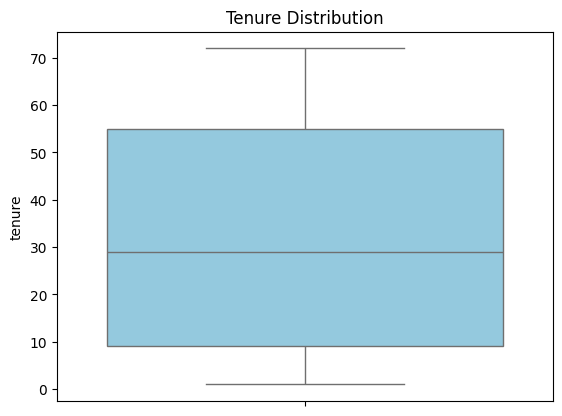

In [15]:
# Tenure
sns.boxplot(y=df["tenure"], color="skyblue")

plt.title("Tenure Distribution")
plt.show()

**Observation:** Customer tenure ranges from 1 to 72 months, with no unusual or extreme values observed.

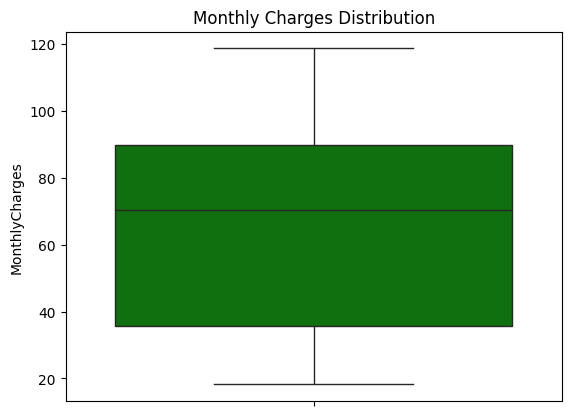

In [16]:
# Montly charges
sns.boxplot(y=df["MonthlyCharges"], color="green")

plt.title("Monthly Charges Distribution")
plt.show()

**Observation:** Monthly charges are reasonably distributed across customers, with no abnormal values detected.

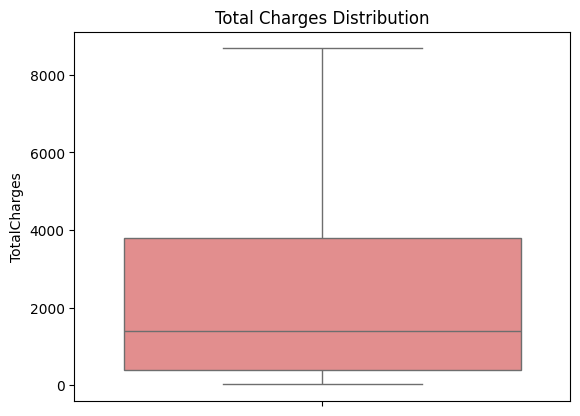

In [17]:
# Total Charges
sns.boxplot(y=df["TotalCharges"], color="lightcoral")

plt.title("Total Charges Distribution")
plt.show()

**Observation:** Total charges show a wider spread, which is expected due to differences in customer tenure and service usage.

### Outlier Analysis

Boxplots were used to examine the numerical features (`tenure`, `MonthlyCharges`, and `TotalCharges`).

The distributions were found to be reasonable, and no invalid outliers were identified. Since the observed extreme values represent actual customer behavior, no outlier removal was required.

### Final Dataset Validation

The dataset was validated after the cleaning process to ensure that all data quality issues were addressed successfully.

Checks performed:
- Verified dataset dimensions
- Confirmed data types
- Ensured no missing values remained
- Confirmed data consistency for further analysis

In [21]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/cleaned_telco_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
